##  الان راح نجرب الانحدار الخطي 

In [30]:
# نقرا الملف 
import pandas as pd 

df = pd.read_csv("car_data.csv")
df.head(6)
#نلاحظ ان في من المتغيرات الدخل فيها قيم نصيه وهذا غير مقبول فلازم نرمزها 

,Brand,Price,Body,Mileage,EngineV,Engine Type,Registration,Year,Model
0,BMW,4200.0,sedan,277,2.0,Petrol,yes,1991,320
1,Mercedes-Benz,7900.0,van,427,2.9,Diesel,yes,1999,Sprinter 212
2,Mercedes-Benz,13300.0,sedan,358,5.0,Gas,yes,2003,S 500
3,Audi,23000.0,crossover,240,4.2,Petrol,yes,2007,Q7
4,Toyota,18300.0,crossover,120,2.0,Petrol,yes,2011,Rav 4
5,Mercedes-Benz,199999.0,crossover,0,5.5,Petrol,yes,2016,GLS 63


In [31]:
# الان نرمز العواميد نصيه 
from sklearn import preprocessing

# اول شي لازم نلائم ثم نرمز 

le_Brand = preprocessing.LabelEncoder()
le_Brand.fit(df['Brand'])

le_Body = preprocessing.LabelEncoder()
le_Body.fit(df['Body'])

le_Engine_Type = preprocessing.LabelEncoder()
le_Engine_Type.fit(df['Engine Type'])

le_Registration = preprocessing.LabelEncoder()
le_Registration.fit(df['Registration'])

le_Model = preprocessing.LabelEncoder()
le_Model.fit(df['Model'])
#  الان راح نسوي عمود جديد ونحط فيه الترميزات 

# الان راح نسوي عمود جديد ونحط فيه الترميزات لكل خاصية
df['Brand_num'] = le_Brand.transform(df['Brand'])
df['Body_num'] = le_Body.transform(df['Body'])
df['Engine_Type_num'] = le_Engine_Type.transform(df['Engine Type'])
df['Registration_num'] = le_Registration.transform(df['Registration'])
df['Model_num'] = le_Model.transform(df['Model'])

# الان راح نحذف الاعمده النصيه و نستبدلها بالترميزات
df = df.drop(columns = ['Brand', 'Body', 'Engine Type', 'Registration', 'Model'])

df.head()


,Price,Mileage,EngineV,Year,Brand_num,Body_num,Engine_Type_num,Registration_num,Model_num
0,4200.0,277,2.0,1991,1,3,3,1,18
1,7900.0,427,2.9,1999,2,5,0,1,266
2,13300.0,358,5.0,2003,2,3,1,1,237
3,23000.0,240,4.2,2007,0,0,3,1,224
4,18300.0,120,2.0,2011,5,0,3,1,227


In [32]:
# راح نشيك على البيانات 
df.info()
# راح نلاحظ انهم كلهم رقمي لكن عمود  السعر و المحرك في في بيانات ناقصه 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4345 entries, 0 to 4344
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Price             4173 non-null   float64
 1   Mileage           4345 non-null   int64  
 2   EngineV           4195 non-null   float64
 3   Year              4345 non-null   int64  
 4   Brand_num         4345 non-null   int64  
 5   Body_num          4345 non-null   int64  
 6   Engine_Type_num   4345 non-null   int64  
 7   Registration_num  4345 non-null   int64  
 8   Model_num         4345 non-null   int64  
dtypes: float64(2), int64(7)
memory usage: 305.6 KB


In [38]:
# راح نستخدم داله fillna عشان نكمل البيانات راح ياخذ المتوسط 

df['Price'].fillna(value = df['Price'].mean(), inplace = True)

df['EngineV'].fillna(value = df['EngineV'].mean(), inplace = True)
df.info()
#بكذا تخلصنا من القيم الفارغه بمتوسط العمود 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4345 entries, 0 to 4344
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Price             4345 non-null   float64
 1   Mileage           4345 non-null   int64  
 2   EngineV           4345 non-null   float64
 3   Year              4345 non-null   int64  
 4   Brand_num         4345 non-null   int64  
 5   Body_num          4345 non-null   int64  
 6   Engine_Type_num   4345 non-null   int64  
 7   Registration_num  4345 non-null   int64  
 8   Model_num         4345 non-null   int64  
dtypes: float64(2), int64(7)
memory usage: 305.6 KB


C:\Users\PC\AppData\Local\Temp\ipykernel_24208\1870865186.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Price'].fillna(value = df['Price'].mean(), inplace = True)
C:\Users\PC\AppData\Local\Temp\ipykernel_24208\1870865186.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.


In [39]:
df.columns

Index(['Price', 'Mileage', 'EngineV', 'Year', 'Brand_num', 'Body_num',
       'Engine_Type_num', 'Registration_num', 'Model_num'],
      dtype='object')

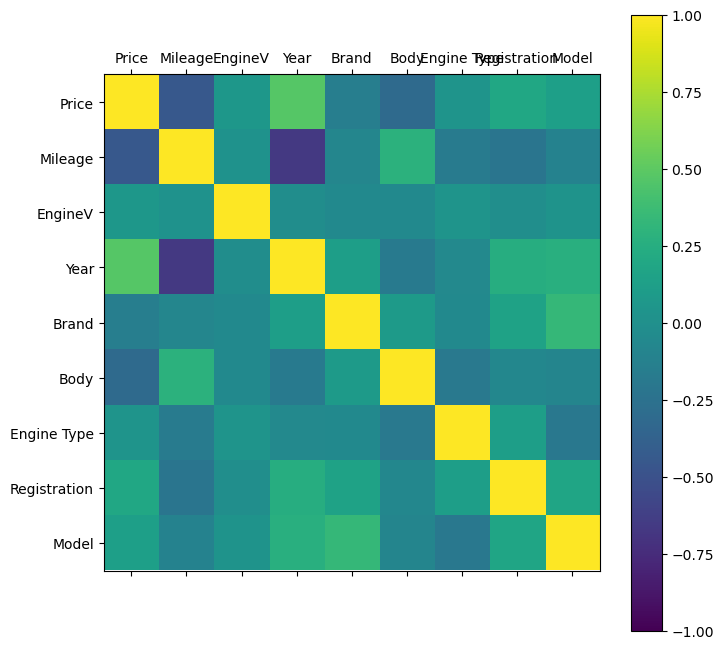

In [49]:
# في بعض الاحيان في الانحدار نحاول نعرف مستوى ترابط المتغيرات ببعضها لاسباب1 عدم ادخال اي متغير لا ياثر في متغير الخرج 
# 2 في حال وجود ترابط بين المتغيرات ندخل واحد فقط  عشان يساهم في دقه النموذج ما يتشتت النموذج 
# person هو معامل يعلمك الترابط بين المتغيرات  1 معناه في ترابط بين العمودين و -1 يعني عكسي 0 مافي علاقه
import matplotlib.pyplot as plt

correlation = df.corr(method = 'pearson')
fig = plt.figure(figsize = (8,8))
ax= fig.add_subplot(1,1,1)
cax = ax.matshow(correlation , vmin = -1, vmax = 1)
fig.colorbar(cax) 
ticks = [0,1,2,3,4,5,6,7,8] 
ax.set_xticks(ticks)
ax.set_yticks(ticks)
ax.set_xticklabels(['Price', 'Mileage', 'EngineV', 'Year', 'Brand', 'Body','Engine Type', 'Registration', 'Model'])
ax.set_yticklabels(['Price', 'Mileage', 'EngineV', 'Year', 'Brand', 'Body','Engine Type', 'Registration', 'Model'])
plt.show()
# هنا يعلمك الترابط بين العواميد

In [51]:
#راح نحدد x  و y في معالدله y=b0+b1*x
x = df[["Year","Mileage","Brand_num","Body_num"]]
y = df["Price"] 

In [52]:
#  train_test_split راح نقسم البيانات الى تدريب و اختبار 
from sklearn.model_selection import  train_test_split

xtrain , xtest , ytrain , ytest = train_test_split(x , y , train_size = 0.8 , random_state = 15)



In [53]:
# الحين راح نبني نموذج الانحدار 
from sklearn.linear_model import LinearRegression

model = LinearRegression()


model.fit(xtrain.values, ytrain)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [55]:
#راح نطلع b0 b1 
model.intercept_


np.float64(-2510620.497546713)

In [56]:
model.coef_

array([ 1271.44214063,   -45.25052754, -2136.87679552, -2785.14366477])

In [57]:

pred = model.predict(xtest)
pred
#وكذا راخ يتنبئ 

C:\Users\PC\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(


array([ 2.63887775e+04,  2.93046387e+04,  1.53101457e+04,  1.09802956e+03,
        2.01126966e+04,  5.11928180e+03,  2.86035068e+03,  8.11826662e+03,
        7.29194763e+03,  3.12944146e+04,  3.22107744e+04,  1.42608041e+04,
        3.11929860e+04,  3.18942959e+04,  2.23299724e+04,  1.59190668e+04,
       -7.81609425e+03,  3.11873114e+04,  2.88908387e+04,  3.02212737e+04,
        2.98929406e+04,  2.16610413e+04,  3.41814086e+04, -1.46100143e+03,
        1.54280028e+04,  2.83647548e+04,  3.49969352e+04,  3.80039042e+04,
        1.85345576e+04,  1.49123525e+04,  2.82966771e+04,  4.56950616e+04,
        3.61623749e+04,  1.18008584e+04,  1.39644845e+04,  1.69024036e+04,
        1.85299002e+04,  2.22061655e+04,  4.61962276e+04,  2.77017284e+04,
        1.85989500e+04,  1.27191511e+04,  1.47425531e+04,  1.98283217e+04,
        1.84983920e+04, -1.24041070e+04,  1.71364037e+04,  2.30411091e+04,
        1.06335648e+04,  2.89495563e+04,  3.71746352e+04,  3.16020835e+04,
       -9.31883965e+02,  

In [59]:
# يعد ما وضحنا الفرق الان نقيس الاداء 
#  يعني تقيس مسافه النفاط عن الخط
#mae يجمعهم ثم يقسم على عددهم 
#rmse يحط على الايرور تربيع ثم يجمع و يقسم على عددهم و بالنهايه يحط جذر  وهذا من نمباي
from sklearn import metrics
import numpy as np

mae = metrics.mean_absolute_error(ytest , pred)

mse = metrics.mean_squared_error(ytest , pred)

rmse = np.sqrt(mse)

print("the mae :", mae)
print("the mse :", mse)
print("the rmse:", rmse)


the mae : 11046.657135188947
the mse : 424253178.97740644
the rmse: 20597.407093549577


In [65]:
#لو السياره كانت بالمواصفات ذي 
year = 2018 
milage = 60 
body= 'sedan'
brand = 'Toyota'

body_num = le_Body.transform([body])[0]
brand_num = le_brand.transform([brand])[0]
example= [[year , milage, body_num , brand_num]]
print(example)
ypred = model.predict(example)
ypred = model.predict(example)
print(ypred)
# تنبئ ان يكون سعرها 32 الف 

[[2018, 60, np.int64(3), np.int64(5)]]
[32098.36189036]
